# Calculate the eigenmodes of a surface mesh (with heterogeneity)

In [2]:
%matplotlib inline

In [3]:
# Import all the libraries
import json
import re
from pathlib import Path
from scipy import stats
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from mpmath import mp
from lapy import Solver, TriaMesh
from lapy.diffgeo import compute_divergence, compute_gradient
from brainspace.mesh import mesh_io, mesh_operations
from scipy.sparse import diags
from scipy.sparse.linalg import LinearOperator, eigsh
from sklearn.preprocessing import MinMaxScaler

In [4]:
# Initialise global variable
DENSITIES = {"32k": 32492}

# Define functions
def calc_determinant(matrix):
    mp.dps = 25
    matrix_mp = [mp.mpf(float(elem)) for elem in matrix]
    det = mp.mpf(1)
    for elem in matrix_mp:
        det *= elem

    return det

def scale_zscore(image, alpha=1.0, cmean=3352.4):
    # Z-score and shift data by c_mean value (from Pang2023)
    return cmean + alpha*stats.zscore(image)

def scale_cmin_cmax(image, alpha=1.0, cmean=3352.4):
    # Calculate normalized density (rho)
    scaler = MinMaxScaler(feature_range=(0, 1))
    rho = scaler.fit_transform(image.reshape(-1, 1)).flatten()

    # Scale rho to be a variation around the mean propagation speed (from Pang2023)
    return cmean + alpha * cmean * (rho - np.mean(rho))

def calc_eig(mesh, n_modes, hetero_map=None, hetero_label=None, cmean=3.3524, alpha=1.0):
    """
    Calculate the eigenvalues and eigenvectors

    Parameters
    ----------
    tria : lapy compatible object
        Loaded vtk object corresponding to a surface triangular mesh
    n_modes : int
        Number of eigenmodes to calculate
    c : array_like
        Spatial map parameterizing heterogeneity. This is done by solving the following
        equation: A @ x[i] = w * B @ C^-1 x[i] where C is the heterogeneity map. If None,
        classic geometric eigenmodes will be calculcated.

    Returns
    -------
    evals : array (n_modes x 1)
        Eigenvalues
    emodes : array (number of surface points x n_modes)
        Eigenmodes
    """

    # Initialise FEM solver
    fem = Solver(mesh)
    if hetero_label is not None:
        # Z-score and shift data by c_mean value (from Pang2023)
        c = scale_cmin_cmax(hetero_map, alpha=alpha, cmean=cmean)
    else:
        c = hetero_map * cmean

    # Ensure c is doesn't have negative values
    assert np.min(c) >= 0.0, f"Minimum value of C is negative: {np.min(c)}"

    # Each term in C needs to be squared (according to the NFT equation)
    c = c ** 2

    # Compute original determinant
    # det = calc_determinant(c)
    # # Set determinant to be 1
    # c = c / np.float32(det**(1/len(c)))
    # new_det = np.float32(calc_determinant(c))
    # assert abs(new_det - 1.0) < 1e-2, f"The new determinant of C is {new_det:.3f} not to 1.0."

    # Matrix multiply B by C^-1 (A @ x = lambda * B @ C^-1 @ x)
    fem.mass = fem.mass @ diags(1 / c, format="csc", dtype="float32")
    # Solve for eigenvalues and eigenmodes
    evals, emodes = fem.eigs(k=n_modes)

    return evals, emodes, c

In [5]:
atlas = "yeo"
space = "fsLR"
den = "32k"
surf_type = "midthickness"
hemi = "L"
n_modes = 5
mask_medial = False
EMODE_DIR = "/fs03/kg98/vbarnes/eigenmodes"
RESULTS_DIR = "/fs04/kg98/vbarnes/HeteroModes/results"
hetero_label = None
scale = "cmin-cmax"
alpha_vals = [0.1, 0.5, 1.0, 1.5, 2.0, 2.5]

In [6]:
# Load map chosen to paramaterize heterogeneity
if hetero_label is not None:
    # Initialise scaling parameters
    scale = scale
    # alpha_vals = [config["alpha"]]
    alpha_vals = alpha_vals

    # Load heterogeneity map
    mode_match = re.search(r"mode(\d+)", hetero_label)
    if mode_match:
        mode_id = int(mode_match.group(1)) - 1
        hetero_modes = np.loadtxt(f"{EMODE_DIR}/hetero-None_atlas-{atlas}_space-{space}_"
                                    f"den-{den}_surf-{surf_type}_hemi-{hemi}_n-{n_modes}_"
                                    f"maskMed-{mask_medial}_emodes.txt")
        hetero_map = hetero_modes[:, mode_id]
    elif hetero_label in config["hetero_maps"]:
        # Load heterogeneity map
        hetero_file = config["hetero_maps"][hetero_label]
        hetero_map = nib.load(hetero_file).agg_data()
    else:
        hetero_map = np.loadtxt(f"./data/hetero-{hetero_label}_surf-{surf_type}.txt")
else:
    # No heterogeneity is encoded by an array of ones
    hetero_map = np.ones(DENSITIES["32k"])
    alpha_vals = [1.0]
    scale = None

In [10]:
# Load surface template and medial wall mask
SURF_DIR = "/fs03/kg98/vbarnes/surfaces"
surf_file = f"{SURF_DIR}/atlas-{atlas}_space-{space}_den-{den}_surf-{surf_type}_hemi-{hemi}"\
    "_surface.vtk"

if mask_medial:
    # Read surface file and medial wall file
    surf = mesh_io.read_surface(surf_file)
    medial = np.loadtxt(f"{SURF_DIR}/atlas-{atlas}_space-{space}_den-{den}_hemi-{hemi}_"
                    f"medialMask.txt").astype(bool)
    # Mask surface template
    surf_masked = mesh_operations.mask_points(surf, medial)
    v = surf_masked.Points
    t = np.reshape(surf_masked.Polygons, [surf_masked.n_cells, 4])[:,1:4]
    mesh = TriaMesh(v, t)
    # Mask heterogeneous map
    hetero_map = hetero_map[medial]
else:
    # Initialise mesh without masking medial wall
    mesh = TriaMesh.read_vtk(surf_file)

--> VTK format         ... 
 --> DONE ( V: 32492 , T: 64980 )



In [11]:
# Initialise parameters
cmean = 3352.4
method = "divgrad"
sigma = -0.01
save_results = False
alpha = 1.0

# Calculate eigenmodes and eigenvalues for each alpha
# for i, alpha in enumerate(alpha_vals):
alpha = f"{alpha:.1f}" if isinstance(alpha, float) else alpha
print(f"Atlas: {atlas} | Space: {space} | Density: {den} | Surface: {surf_type} | "
    f"Hetero: {hetero_label} | Scaling: {scale} | alpha: {alpha} | Method: {method}")
desc = f"hetero-{hetero_label}_atlas-{atlas}_space-{space}_den-{den}_surf-{surf_type}_" \
    f"hemi-{hemi}_n-{n_modes}_scale-{scale}_alpha-{alpha}_method-{method}_maskMed-{mask_medial}"

if hetero_label is not None:
    # Z-score and shift data by c_mean value (from Pang2023)
    c = scale_cmin_cmax(hetero_map, alpha=alpha, cmean=cmean)
else:
    c = hetero_map * cmean

# Ensure c is doesn't have negative values
assert np.min(c) >= 0.0, f"Minimum value of C is negative: {np.min(c)}"
# Each term in C needs to be squared (according to the NFT equation)
c = c ** 2

if method == "divgrad":
    print("Using divgrad method")
    # fem = Solver(mesh, lump=True)
    # mass_inv = fem.mass.copy()
    # mass_inv.data **= -1

    class DivGradOperator(LinearOperator):
        def __init__(self, geom, dtype="float32"):
            self.geom = geom
            self.shape = (geom.v.shape[0], geom.v.shape[0])
            self.dtype = np.dtype(dtype)
        def _matvec(self, vfunc):
            """Compute the effect of the operator on the input vector vfunc."""
            return -compute_divergence(self.geom, compute_gradient(self.geom, vfunc))

    divgrad_op = DivGradOperator(mesh, dtype="float32")
    evals, emodes = eigsh(divgrad_op, n_modes, sigma=sigma)
elif method == "femsolver":
    print("Using femsolver method")
    # Initialise FEM solver
    fem = Solver(mesh)
    # Modify mass matrix (B), by multiplying it by C^-1 (A @ x = lambda * B @ C^-1 @ x)
    fem.mass = fem.mass @ diags(1 / c, format="csc", dtype="float32")
    # Solve for eigenvalues and eigenmodes
    evals, emodes = fem.eigs(k=n_modes)
    # evals, emodes = eigsh(fem.stiffness, n_modes, fem.mass, sigma=sigma, OPinv=None)
else:
    raise ValueError(f"{method} is not a compatible method")

# Reshape emodes to match vertices of original surface
medial_inds = np.array([i for i, med in enumerate(medial) if med])
if mask_medial:
    emodes_reshaped = np.zeros([surf.n_points, n_modes])
    for mode in range(n_modes):
        emodes_reshaped[medial_inds, mode] = emodes[:, mode]
    emodes = emodes_reshaped
    # Reshape propagation speed map
    c_reshaped = np.zeros([surf.n_points])
    c_reshaped[medial_inds] = c
    c = c_reshaped

# Set output filenames and save
if save_results:
    print("Saving eigenmodes, eigenvalues and cmap...")
    evals_savefile = Path(EMODE_DIR, f"{desc}_evals.txt")
    emodes_savefile = Path(EMODE_DIR, f"{desc}_emodes.txt")
    cmap_savefile = Path(RESULTS_DIR, "cmaps", f"{desc}_cmap.txt")
    np.savetxt(evals_savefile, evals)
    np.savetxt(emodes_savefile, emodes)
    np.savetxt(cmap_savefile, c_reshaped)

Atlas: yeo | Space: fsLR | Density: 32k | Surface: midthickness | Hetero: None | Scaling: None | alpha: 1.0 | Method: divgrad
Using divgrad method


ValueError: shape mismatch: value array of shape (32492,) could not be broadcast to indexing result of shape (29696,)

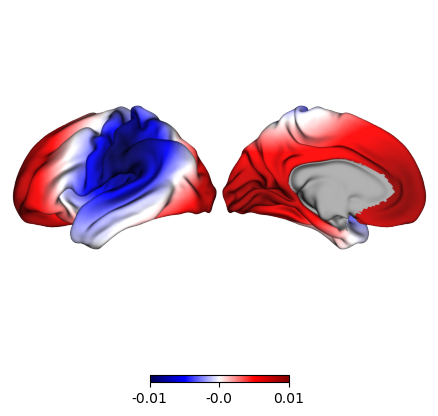

In [38]:
from surfplot import Plot
from scipy.stats.mstats import winsorize

mode = 3

# fem = Solver(mesh, lump=True)
# Binv = fem.mass.copy()
# Binv.data **= -1
# test_mode = np.zeros(32492)
# test_mode[medial_inds] = emodes[medial_inds, mode] #* Binv

# test_mode = winsorize(test_mode, limits=[0.01, 0.01])

p = Plot(surf_lh=surf, zoom=1.25)
p.add_layer({"left": emodes[:, mode]}, cmap="seismic", cbar=True)
fig = p.build()
fig.show()

In [12]:
# Compare with original geometric modes
from neuromaps.stats import compare_images

# Load geometric eigenmodes and eigenvalues
geom_desc = f"hetero-None_atlas-yeo_space-fsLR_den-32k_surf-midthickness_hemi-L_n-200_"\
    "scale-cmean-3352.4_alpha-None_method-modMass_maskMed-True"
geom_modes = np.loadtxt(Path(EMODE_DIR, f"{geom_desc}_emodes.txt"))
geom_evals = np.loadtxt(Path(EMODE_DIR, f"{geom_desc}_evals.txt"))

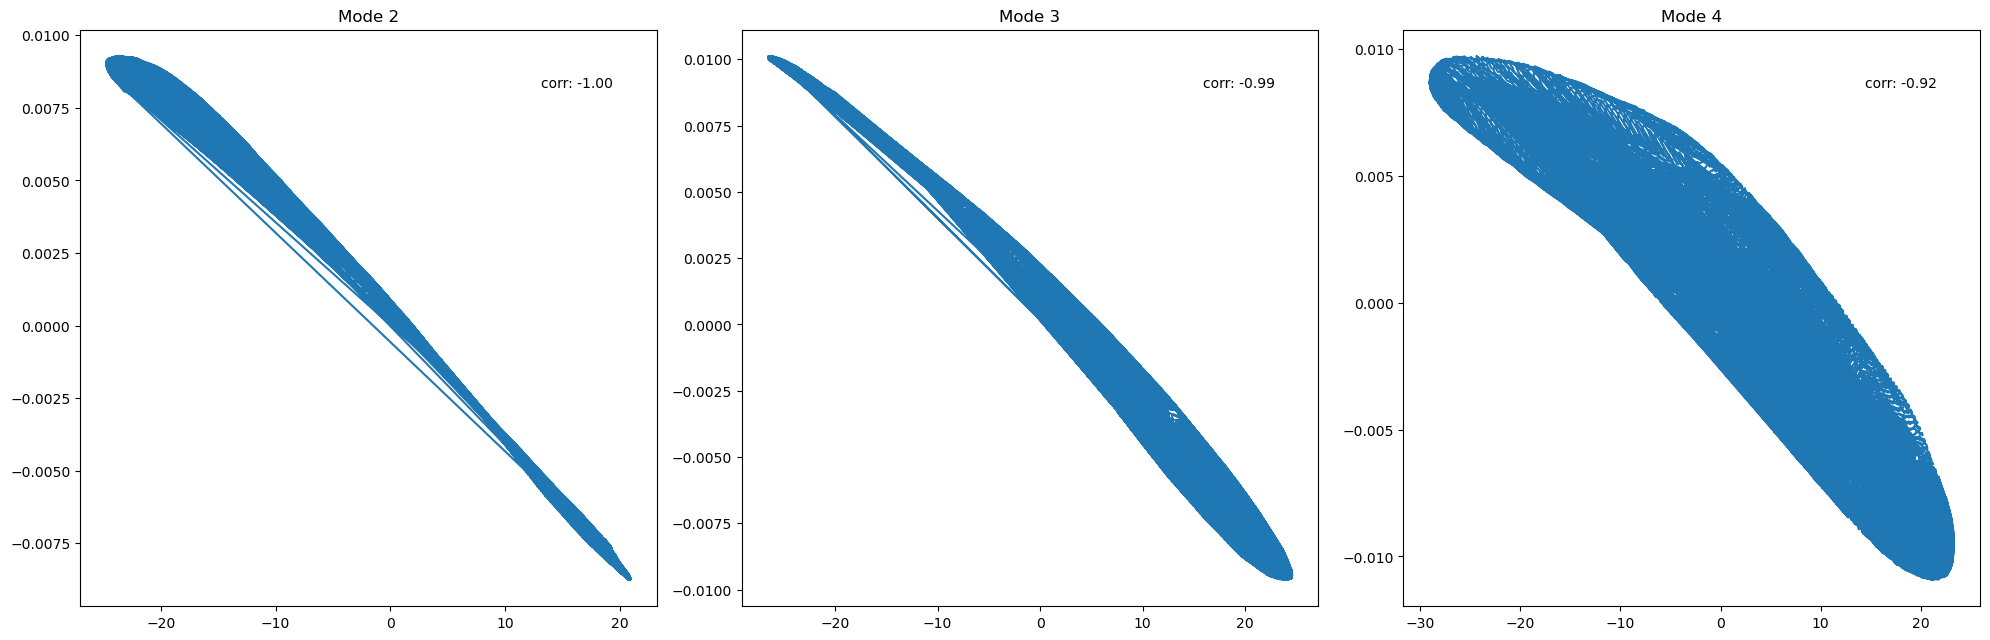

In [59]:
mode = 3
fig, axs = plt.subplots(1, 3, figsize=(20, 8))
axs = axs.ravel()
for i, mode in enumerate([1, 2, 3]):
    axs[i].plot(geom_modes[medial_inds, mode], emodes[medial_inds, mode])

    corr = compare_images(geom_modes[medial_inds, mode], emodes[medial_inds, mode], ignore_zero=False)
    axs[i].text(0.8, 0.9, f"corr: {corr:.2f}", transform=axs[i].transAxes)
    axs[i].set_title(f"Mode {i+2}")
    axs[i].set_box_aspect(1)

plt.tight_layout()
plt.show()